In [1]:
##LIBRERIAS##
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
##CARGA DE DATOS## 
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                
                continue

    return np.array(columnas)

In [15]:
##GRAFICA Y AJUSTE##
def plot_ajuste(x, z, y,err_z, err_y, err_x, tittle, x_tittle, y_tittle,z_ajuste, 
                x_ajuste, y_ajuste, residuales_norm1, residuales_norm2, z_legend = "D2", y_legend = "D1",
                color_n1="#D6259B", color_n2="#51D63F"):

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 14), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )
    
    # --- Gráfico principal ---
    ax1.set_title(tittle, fontsize=22, weight="bold")
    ax1.set_ylabel(x_tittle, fontsize=20)
    ax1.tick_params(axis="both", labelsize=20, width=2)  # ticks más grandes y gruesos
    ax1.grid(True, alpha=0.3)

    # Ejes más gruesos
    for spine in ax1.spines.values():
        spine.set_linewidth(2)

    ax1.errorbar(
        x, y, xerr=err_x, yerr=err_y,
        fmt="v", markersize=10, mfc=color_n1, mec="black",
        elinewidth=2, capthick=2, color=color_n1,
        label= y_legend + " con error"
    )
    ax1.errorbar(
        x, z, xerr=err_x, yerr=err_z,
        fmt="o", markersize=10, mfc=color_n2, mec="black",
        elinewidth=2, capthick=2, color=color_n2,
        label= z_legend + " con error"
    )   

    ax1.plot(x_ajuste, y_ajuste, "--", linewidth=3,
             color="black", label="Línea de ajuste")
    ax1.plot(x_ajuste, z_ajuste, "--", linewidth=3,
             color="gray", label="Línea de ajuste")
    ax1.legend(fontsize=16)

    # --- Gráfico de residuales ---
    ax2.set_xlabel(y_tittle, fontsize=20)
    ax2.set_ylabel("Residuales\n(normalizados)", fontsize=20)
    ax2.tick_params(axis="both", labelsize=20, width=2)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=2)

    for spine in ax2.spines.values():
        spine.set_linewidth(2)

    ax2.scatter(x, residuales_norm1, color=color_n2, s=90, edgecolor="black")
    ax2.scatter(x, residuales_norm2, color=color_n1, s=90, edgecolor="black")
    ax2.grid(True, alpha=0.3)
    ax1.set_xlim(0, max(x) + 0.01)
    plt.tight_layout()
    plt.show()


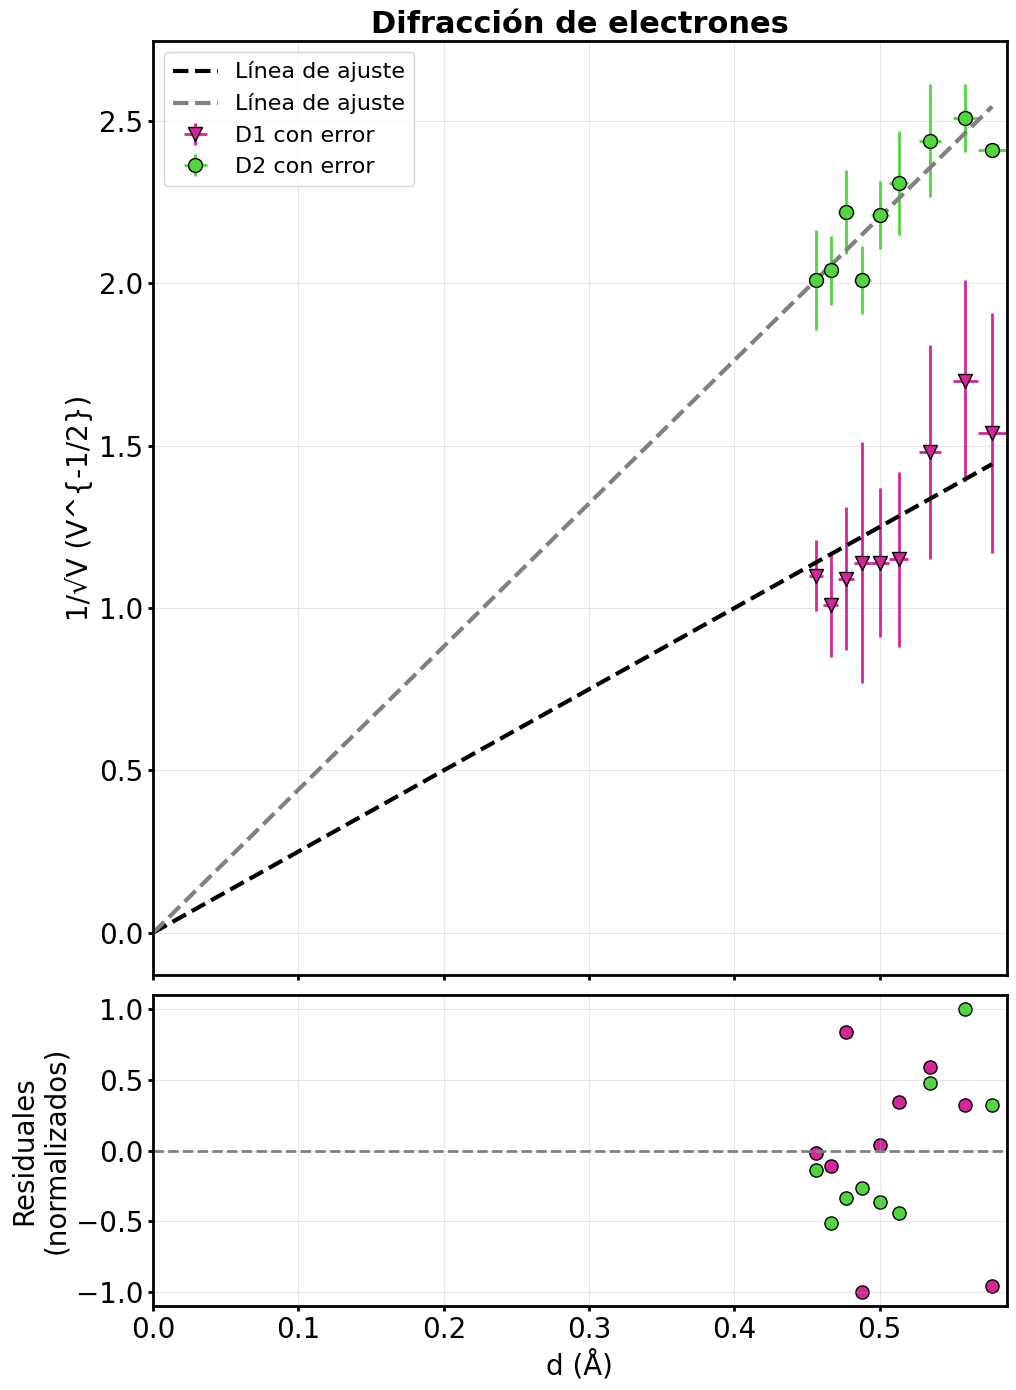

In [21]:
# --- CARGA Y PREPARACIÓN ---
archivo = "toma_de_Datos.txt"
archivo2 = "toma_de_datos_2.txt"
data = leer_columnas(archivo)
data2 = leer_columnas(archivo2)

x = 1 / (data[0]**(1/2))
err_x = 1 / (data[0]**(3/2)) * data[1] / 2
y = data2[2][:9]
err_y = data2[3][:9]
z = data[4]
err_z = data[5]

# --- AJUSTE LINEAL FORZADO A ORIGEN (y vs x) ---
A = x.reshape(-1, 1)  # diseño sin columna de 1's -> ajuste sin intercepto
coef_y, *_ = np.linalg.lstsq(A, y, rcond=None)
mfit_y = float(coef_y[0])
bfit_y = 0.0

# incertidumbre de la pendiente (covarianza simplificada)
N = x.size
p = 1
y_pred = mfit_y * x
SSE_y = np.sum((y - y_pred)**2)
sigma2_y = SSE_y / (N - p) if N - p > 0 else 0.0
var_m_y = sigma2_y / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_y = np.sqrt(var_m_y)
sbfit_y = 0.0

# Extender la línea de ajuste hasta x=0 para que toque (0,0)
x_ajuste = np.linspace(0, x.max(), 200)
y_ajuste = mfit_y * x_ajuste  # pasa por el origen

# residuales normalizados (y)
resid_y = y - (mfit_y * x + bfit_y)
max_abs_res_y = np.max(np.abs(resid_y))
if max_abs_res_y == 0:
    residuales_norm1 = np.zeros_like(resid_y)
    err_res_norm1 = np.zeros_like(err_y)
else:
    residuales_norm1 = resid_y / max_abs_res_y
    err_res_norm1 = err_y / max_abs_res_y

# --- AJUSTE LINEAL FORZADO A ORIGEN (z vs x) ---
coef_z, *_ = np.linalg.lstsq(A, z, rcond=None)
mfit_z = float(coef_z[0])
bfit_z = 0.0

z_pred = mfit_z * x
SSE_z = np.sum((z - z_pred)**2)
sigma2_z = SSE_z / (N - p) if N - p > 0 else 0.0
var_m_z = sigma2_z / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_z = np.sqrt(var_m_z)
sbfit_z = 0.0

# extender también la línea de ajuste de z hasta x=0
z_ajuste = mfit_z * x_ajuste  # pasa por el origen

# residuales normalizados (z)
resid_z = z - (mfit_z * x + bfit_z)
max_abs_res_z = np.max(np.abs(resid_z))
if max_abs_res_z == 0:
    residuales_norm2 = np.zeros_like(resid_z)
    err_res_norm2 = np.zeros_like(err_z)
else:
    residuales_norm2 = resid_z / max_abs_res_z
    err_res_norm2 = err_z / max_abs_res_z

# --- PLOT ---
plot_ajuste(
    x, z, y, err_z, err_y, err_x,
    tittle="Difracción de electrones",
    x_tittle="1/√V (V^{-1/2})",
    y_tittle="d (Å)",
    z_ajuste=z_ajuste,
    x_ajuste=x_ajuste,
    y_ajuste=y_ajuste,
    residuales_norm1=residuales_norm1,
    residuales_norm2=residuales_norm2
)

In [ ]:
##Valor esperado de la pendiente## 
from scipy.constants import h, m_e, e

slope_expected_m = h / np.sqrt(2 * m_e * e)  # en metros
slope_expected_A = slope_expected_m * 1e10   # convertir a Ångström

lambda_broglie = slope_expected_A  # pendiente esperada en Å (para y vs 1/sqrt(V))

print(f"Pendiente esperada: {lambda_broglie:.3e} Å") 


# --- CARGA Y PREPARACIÓN ---
archivo = "toma_de_Datos.txt"
data = leer_columnas(archivo)

x = 1 / (data[0]**(1/2))
err_x = 1 / (data[0]**(3/2)) * data[1] / 2
y = data[2]
err_y = data[3]
z = data[4]
err_z = data[5]

# --- AJUSTE LINEAL FORZADO A ORIGEN (y vs x) ---
A = x.reshape(-1, 1)  # diseño sin columna de 1's -> ajuste sin intercepto
coef_y, *_ = np.linalg.lstsq(A, y, rcond=None)
mfit_y = float(coef_y[0])
bfit_y = 0.0

# incertidumbre de la pendiente (covarianza simplificada)
N = x.size
p = 1
y_pred = mfit_y * x
SSE_y = np.sum((y - y_pred)**2)
sigma2_y = SSE_y / (N - p) if N - p > 0 else 0.0
var_m_y = sigma2_y / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_y = np.sqrt(var_m_y)
sbfit_y = 0.0

# Extender la línea de ajuste hasta x=0 para que toque (0,0)
x_ajuste = np.linspace(0, x.max(), 200)
y_ajuste = mfit_y * x_ajuste  # pasa por el origen

# residuales normalizados (y)
resid_y = y - (mfit_y * x + bfit_y)
max_abs_res_y = np.max(np.abs(resid_y))
if max_abs_res_y == 0:
    residuales_norm1 = np.zeros_like(resid_y)
    err_res_norm1 = np.zeros_like(err_y)
else:
    residuales_norm1 = resid_y / max_abs_res_y
    err_res_norm1 = err_y / max_abs_res_y

# --- AJUSTE LINEAL FORZADO A ORIGEN (z vs x) ---
coef_z, *_ = np.linalg.lstsq(A, z, rcond=None)
mfit_z = float(coef_z[0])
bfit_z = 0.0

z_pred = mfit_z * x
SSE_z = np.sum((z - z_pred)**2)
sigma2_z = SSE_z / (N - p) if N - p > 0 else 0.0
var_m_z = sigma2_z / np.sum(x**2) if np.sum(x**2) != 0 else 0.0
smfit_z = np.sqrt(var_m_z)
sbfit_z = 0.0

# extender también la línea de ajuste de z hasta x=0
z_ajuste = mfit_z * x_ajuste  # pasa por el origen

# residuales normalizados (z)
resid_z = z - (mfit_z * x + bfit_z)
max_abs_res_z = np.max(np.abs(resid_z))
if max_abs_res_z == 0:
    residuales_norm2 = np.zeros_like(resid_z)
    err_res_norm2 = np.zeros_like(err_z)
else:
    residuales_norm2 = resid_z / max_abs_res_z
    err_res_norm2 = err_z / max_abs_res_z

# --- PLOT ---
plot_ajuste(
    x, z, y, err_z, err_y, err_x,
    tittle="Difracción de electrones",
    x_tittle="1/√V (V^{-1/2})",
    y_tittle="d (Å)",
    z_ajuste=z_ajuste,
    x_ajuste=x_ajuste,
    y_ajuste=y_ajuste,
    residuales_norm1=residuales_norm1,
    residuales_norm2=residuales_norm2
)

Pendiente esperada: 1.226e+01 Å
